In [2]:
import pandas as pd
df=pd.read_csv("D:/netflix_user_behavior_dataset.csv")
df.head(10)

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No
5,U100005,38,Female,France,23,Standard,12.99,PayPal,Tablet,2,Documentary,92,11,1,46,3.9,15,36,18,No
6,U100006,56,Other,Brazil,11,Basic,15.99,Credit Card,Tablet,1,Documentary,111,9,12,93,3.3,45,46,2,No
7,U100007,36,Other,Australia,46,Standard,15.99,PayPal,Mobile,3,Sci-Fi,293,10,2,81,1.7,42,35,59,No
8,U100008,40,Female,Australia,20,Basic,12.99,Credit Card,Laptop,2,Romance,202,7,9,60,2.0,15,24,31,No
9,U100009,28,Female,UK,7,Premium,15.99,UPI,Mobile,2,Action,246,2,5,55,4.9,11,17,31,Yes


In [3]:
df.shape

(50000, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [5]:
df.isnull().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

In [6]:
# Now we need to calculate how manny churned out

df['churned'].value_counts()

churned
No     40036
Yes     9964
Name: count, dtype: int64

# A 20% churn rate is serious for subscription platform 
# This validates that: Netflix is experiencing significant user churn and wants the product analytics team to identify the casues

In [7]:
# Now we start investigation, who is leaving the platform ?
pd.crosstab(df['subscription_type'],df['churned'])

churned,No,Yes
subscription_type,,
Basic,12012,2861
Premium,12097,3099
Standard,15927,4004


In [8]:
pd.crosstab(df['primary_device'],df['churned'])

churned,No,Yes
primary_device,,
Laptop,9971,2538
Mobile,10057,2528
Smart TV,10102,2460
Tablet,9906,2438


In [9]:
pd.crosstab(df['favorite_genre'],df['churned'])

churned,No,Yes
favorite_genre,,
Action,5034,1201
Comedy,5003,1256
Documentary,5101,1251
Drama,4998,1205
Horror,4957,1266
Romance,5013,1269
Sci-Fi,4956,1233
Thriller,4974,1283


In [10]:
# Counts alone don't clear the picture because each category has different total users

In [11]:
pd.crosstab(df['subscription_type'],df['churned'],normalize='index')*100

churned,No,Yes
subscription_type,,
Basic,80.763800,19.236200
Premium,79.606475,20.393525
Standard,79.910692,20.089308


In [12]:
pd.crosstab(df['primary_device'],df['churned'],normalize='index')*100

churned,No,Yes
primary_device,,
Laptop,79.710608,20.289392
Mobile,79.912594,20.087406
Smart TV,80.417131,19.582869
Tablet,80.249514,19.750486


In [13]:
pd.crosstab(df['favorite_genre'],df['churned'],normalize='index')*100

churned,No,Yes
favorite_genre,,
Action,80.737771,19.262229
Comedy,79.932897,20.067103
Documentary,80.305416,19.694584
Drama,80.573916,19.426084
Horror,79.656114,20.343886
Romance,79.799427,20.200573
Sci-Fi,80.077557,19.922443
Thriller,79.494966,20.505034


# We discovered that churn is evenly distributed, no major signal from subscription/device/genre alone, 
# meaning deeper behavioral factors probably drive churn
# Now we move to User Engagement Behavior, this is where strong insights usually appear

In [14]:
df.groupby('churned')[['avg_watch_time_minutes','watch_sessions_per_week','binge_watch_sessions','completion_rate','content_interactions','recommendation_click_rate','days_since_last_login']].mean()

,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,content_interactions,recommendation_click_rate,days_since_last_login
churned,,,,,,,
No,155.156284,9.996503,7.009641,64.551953,24.354881,49.595514,29.406609
Yes,154.103673,9.948414,6.973906,64.458952,24.111501,49.432356,29.426234


In [15]:
# We expected churned users to behave very differently, but averages are almost identical. 
# This means: churn is Not explained well by simple averages,
# we need deeper segmentations
# and probably combination of behaviors matters

In [16]:
# Now let's test an important product analytics hypothesis: "users inactive for long periods are more likely to churn"
pd.qcut(df['days_since_last_login'],4)

0          (14.0, 29.0]
1        (-0.001, 14.0]
2          (29.0, 44.0]
3          (14.0, 29.0]
4          (44.0, 59.0]
              ...      
49995    (-0.001, 14.0]
49996      (29.0, 44.0]
49997      (14.0, 29.0]
49998      (29.0, 44.0]
49999      (14.0, 29.0]
Name: days_since_last_login, Length: 50000, dtype: category
Categories (4, interval[float64, right]): [(-0.001, 14.0] < (14.0, 29.0] < (29.0, 44.0] < (44.0, 59.0]]

In [17]:
df.groupby(pd.qcut(df['days_since_last_login'],4))['churned'].value_counts(normalize=True)*100

C:\Users\Sujal Gupta\AppData\Local\Temp\ipykernel_22156\2728137401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['days_since_last_login'],4))['churned'].value_counts(normalize=True)*100


days_since_last_login  churned
(-0.001, 14.0]         No         80.151636
                       Yes        19.848364
(14.0, 29.0]           No         79.895850
                       Yes        20.104150
(29.0, 44.0]           No         80.303399
                       Yes        19.696601
(44.0, 59.0]           No         79.942257
                       Yes        20.057743
Name: proportion, dtype: float64

# Again churn is almost evenly distributed, this tells us something very important: The dataset is synthetically balaced
# Meaning : variables are randomly distributed, strong real world behavioral patterns are weak, 
#         : so we won't get naturally strong business insights from simple grouping
# Now we find correlation between numerical features, to identify which metrics move together ?

In [18]:
numerical_cols = [
    "age",
    "account_age_months",
    "monthly_fee",
    "devices_used",
    "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "binge_watch_sessions",
    "completion_rate",
    "rating_given",
    "content_interactions",
    "recommendation_click_rate",
    "days_since_last_login"
]

df[numerical_cols].corr()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
age,1.000000,-0.003321,-0.001249,0.003628,0.002986,-0.003903,-0.001585,0.001884,-0.000391,-0.003516,-0.005728,0.002316
account_age_months,-0.003321,1.000000,0.002198,-0.002959,-0.006862,-0.013159,-0.000585,0.006694,-0.001006,-0.001570,-0.002141,0.002224
monthly_fee,-0.001249,0.002198,1.000000,0.005897,0.003458,-0.005715,0.004547,0.003470,0.002812,-0.001833,-0.004925,-0.004023
devices_used,0.003628,-0.002959,0.005897,1.000000,0.013087,-0.002001,-0.001009,-0.009371,0.006082,-0.003282,-0.002793,0.007411
avg_watch_time_minutes,0.002986,-0.006862,0.003458,0.013087,1.000000,-0.003279,0.003524,0.000271,0.004189,0.001227,0.003331,0.003144
watch_sessions_per_week,-0.003903,-0.013159,-0.005715,-0.002001,-0.003279,1.000000,-0.000557,-0.005760,0.005397,-0.006648,-0.001623,0.006993
binge_watch_sessions,-0.001585,-0.000585,0.004547,-0.001009,0.003524,-0.000557,1.000000,0.005352,-0.005403,0.000868,0.005332,0.000527
completion_rate,0.001884,0.006694,0.003470,-0.009371,0.000271,-0.005760,0.005352,1.000000,0.001304,0.002257,-0.003779,-0.001558
rating_given,-0.000391,-0.001006,0.002812,0.006082,0.004189,0.005397,-0.005403,0.001304,1.000000,0.002362,0.006683,-0.005846
content_interactions,-0.003516,-0.001570,-0.001833,-0.003282,0.001227,-0.006648,0.000868,0.002257,0.002362,1.000000,-0.004982,-0.001302


In [19]:
churn_rate=((df['churned']=='Yes').sum()/len(df))*100
print('churn rate: ',round(churn_rate,2),'%')

churn rate:  19.93 %


# Netflix Churn Rate=19.93 %

In [20]:
# Retention Rate:
retention_rate=100-churn_rate
print(retention_rate," %")

80.072  %


# Average Watch Time

In [21]:
print(df['avg_watch_time_minutes'].mean())

154.94652


# Compare watch time between Churned vs Retained users

In [22]:
df.groupby('churned')['avg_watch_time_minutes'].mean()

churned
No     155.156284
Yes    154.103673
Name: avg_watch_time_minutes, dtype: float64

In [23]:
# Watch time alone is NOT strongly explaining churn, This is very realistic analyst conclusion

In [24]:
# Most Engaged Users

In [25]:
df[[ "avg_watch_time_minutes",
    "watch_sessions_per_week",
    "binge_watch_sessions",
    "content_interactions",
    "recommendation_click_rate"]].describe()

,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,content_interactions,recommendation_click_rate
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,154.946520,9.986920,7.002520,24.306380,49.563000
std,83.727292,5.480616,4.335819,14.468037,28.816997
min,10.000000,1.000000,0.000000,0.000000,0.000000
25%,83.000000,5.000000,3.000000,12.000000,25.000000
50%,155.000000,10.000000,7.000000,24.000000,50.000000
75%,228.000000,15.000000,11.000000,37.000000,75.000000
max,299.000000,19.000000,14.000000,49.000000,99.000000


# Now we will identify Highly and low Engaged Users based on watch time

In [26]:
df['engagement_level']=df['avg_watch_time_minutes'].apply(lambda x: 'High' if x>155 else 'Low')
df['engagement_level'].value_counts()

engagement_level
Low     25066
High    24934
Name: count, dtype: int64

# Now the important question comes that: 'do low engagement users churn more?'

In [27]:
pd.crosstab(df['engagement_level'],df['churned'],normalize='index')*100

churned,No,Yes
engagement_level,,
High,80.231812,19.768188
Low,79.913030,20.086970


# Low engagement users churn slightly more, this supports product hypothesis: increasing user engagement may help improve retention:
1. Introduce targert free trial retention campaigns with auto renew incentives for low engagement users
2. Conduct preference analysis and surveys to identify trending genres among low engagement users and improve content acquisition strategy.
3. Launch tiered and personalized subscription plans to improve affordability and user retention across different custome segmetns.


In [28]:
import matplotlib.pyplot as plt 
import seaborn as sns

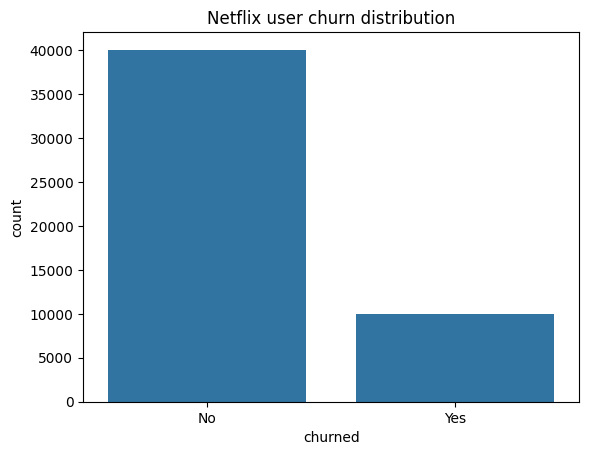

In [29]:
sns.countplot(x='churned',data=df)
plt.title('Netflix user churn distribution')
plt.show()

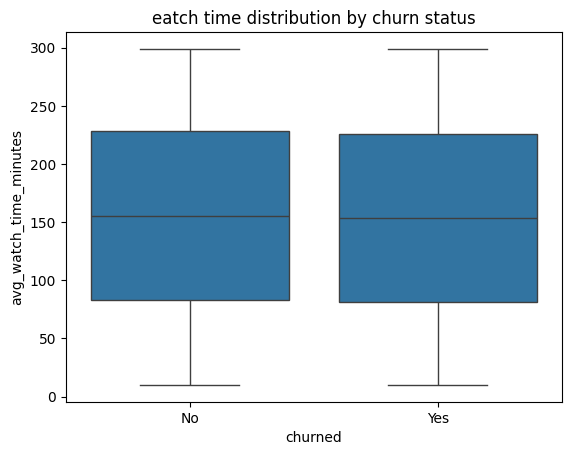

In [30]:
sns.boxplot(x='churned',y='avg_watch_time_minutes',data=df)
plt.title('eatch time distribution by churn status')
plt.show()

# Boxplot shows median, spread, variability, and outliers; Both churned and retained users have almost identical 
# median watch time, similar spread, similar variability
# So visually also: watch time alone doesn't strongly separate churned users from retained users.
# This confirms our earlier numerical analysis

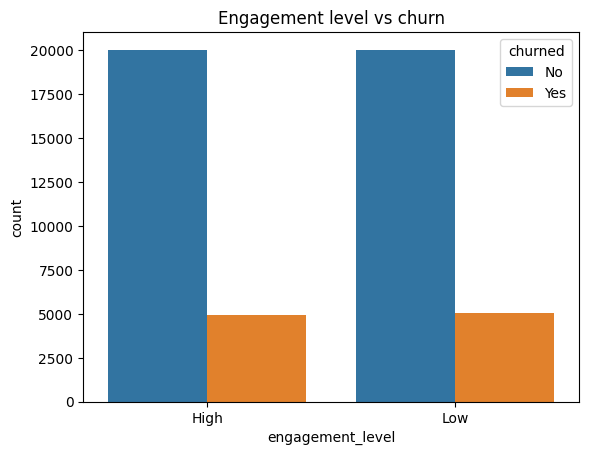

In [31]:
sns.countplot(x='engagement_level',hue='churned',data=df)
plt.title('Engagement level vs churn')
plt.show()

    # Both engagement groups retain most users
    # Low engagement users show slightly higher churn
    # This suggests Netflix should improve engagement focused retention strategies for low activity users

# Our analysis revealed that churn was relatively evenly distributed across genres, subscription types, and device
# categories, indicating that no single demographic or content segment was solely responsible for customer drop-off. 
# Further behavioral analysis showed minimal variation between churned and retained uses in terms of average engagement
# metrics, watch time, and numerical feature correlations, suggesting that churn behavior is influenced by more complex
# user patterns rather than isolate variables.
# To investigate deeper, users were segemented into high and low engagement groups based on watch time behavior, 
# Although churn differences remained modest, low-engagement users exhibited slightly higher churn tendencies. Based
# on these findings, Netflix should prioritize strategies focused on increasing user engagement and platform stickiness
# among at risk users
# Recommended actions include:
    # introducing targeted free trails retention campaigns with auto renewal incentives
    # conducting genre preference surveys for low engagement users to improve content personalization
    # and offering tiered subscription plans to better match varying customer affordability and usage patterns

#
1. Project Title : Netflix User Engagement and Churn Analysis
2. Business Problem : Netflix is experiencing customer churn, affecting long-term user retention and subscription                       growth. The objective of this project is to identify behavioral patterns associated with                          churn and recommend strategies to improve user engagement and retention.
3. Key KPI's : Churn Rate
               Retention Rate
               Engagement Level
               Average Watch Time
               Watch Sessions per Week
4. Major Findings : Churn was evenly distributed across genres, subscription types, and device categories,                            indicating that customer drop-off is not driven by a single demographic or content factor.                        Behavioral analysis showed that low-engagement users exhibited slightly higher churn                              tendencies, suggesting that engagement-related factors play a more important role in                              retention.
5. Recommendations : Introduce free-trial retention campaigns with auto-pay incentives
                     Conduct genre-preference surveys to improve personalized recommendations
                     Offer tiered subscription pricing for different user segments

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   country                    50000 non-null  object 
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  object 
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  object 
 8   primary_device             50000 non-null  object 
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  object 
 11  avg_watch_time_minutes     50000 non-null  int64  
 12  watch_sessions_per_week    50000 non-null  int64  
 13  binge_watch_sessions       50000 non-null  int

In [33]:
df.to_csv('Netflix_final_project.csv',index=False)